# image classification

In [1]:
# fmnist dataset image classification using cnn
import tensorflow as tf
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
# check tensorflow version
print(tf.__version__)

2.10.0


In [20]:
# load the fmnist dataset
fmnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fmnist.load_data()

# normalize the images
train_images = train_images / 255
test_images = test_images / 255

# print the shape of the dataset
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


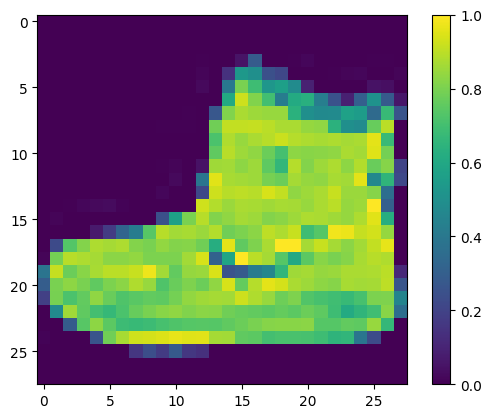

In [21]:
# display the first 25 images from the training set
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

In [22]:
# display the value of each pixel in the range after normalization
print('\n Pixel value after normalization:')
for row in train_images[0]:
    for pixel in row:
        print(f"{float(pixel):0.1}", end=" ")
    print()


 Pixel value after normalization:
0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 
0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 
0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 
0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0.004 0e+00 0e+00 0.05 0.3 0e+00 0e+00 0.004 0.02 0e+00 0e+00 0e+00 0e+00 0.004 0.004 0e+00 
0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0.01 0e+00 0.1 0.5 0.5 0.2 0.2 0e+00 0e+00 0e+00 0.004 0.01 0.02 0e+00 0e+00 0.01 
0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0e+00 0.02 0e+00 0.4 0.8 0.7 0.5 0.6 0.5 0.09 0e+00 0e+00 0e+00 0e+00 0.

<Figure size 640x480 with 0 Axes>

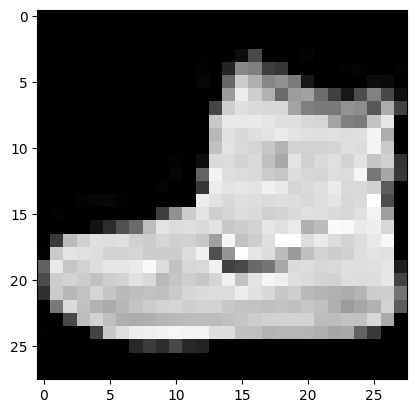

In [23]:
 # reshape the images to have a channel dimension
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# display the complete output of the cell 
display(plt.gcf())
plt.imshow(train_images[0], cmap='gray')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# create an input layer
input_layer = tf.keras.layers.Input(shape=(28, 28, 1)) # 28x28 pixel image with a sigle color channel 

# CNN modle building 
model = tf.keras.Sequential([
    input_layer,
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
    # filter is the number if filters we will to apply 
    # kernel is the size of windows/filter moving over the image 
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
    layers.MaxPooling2D(pool_size=(3, 3)), # pooling layer

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(), # pooling layer

    layers.Flatten(), # flatten layer
    layers.Dense(10, activation='softmax') # output layer # why we did add 10?

])
# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 conv2d_7 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 6, 6, 64)          36928     
                                                                 
 conv2d_9 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 2, 2, 64)         0         
 2D)                                                  

In [43]:
# trian the model
model.fit(train_images, train_labels, epochs=20, batch_size=32, validation_data=(test_images, test_labels))


Epoch 1/20
1875/1875 [==============================] - 153s 81ms/step - loss: 0.1103 - accuracy: 0.9598 - val_loss: 0.2773 - val_accuracy: 0.9144
Epoch 2/20
1875/1875 [==============================] - 172s 92ms/step - loss: 0.1015 - accuracy: 0.9629 - val_loss: 0.2837 - val_accuracy: 0.9148
Epoch 3/20
1875/1875 [==============================] - 204s 109ms/step - loss: 0.0908 - accuracy: 0.9665 - val_loss: 0.3049 - val_accuracy: 0.9131
Epoch 4/20
1875/1875 [==============================] - 211s 113ms/step - loss: 0.0838 - accuracy: 0.9690 - val_loss: 0.3088 - val_accuracy: 0.9127
Epoch 5/20
1875/1875 [==============================] - 184s 98ms/step - loss: 0.0776 - accuracy: 0.9711 - val_loss: 0.3170 - val_accuracy: 0.9140
Epoch 6/20
1875/1875 [==============================] - 203s 108ms/step - loss: 0.0699 - accuracy: 0.9739 - val_loss: 0.3593 - val_accuracy: 0.9114
Epoch 7/20
1875/1875 [==============================] - 155s 83ms/step - loss: 0.0661 - accuracy: 0.9759 - val_loss

In [ ]:
# model evaluation
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc}")
print(f"Test loss: {test_loss}")

313/313 [==============================] - 13s 41ms/step - loss: 0.2549 - accuracy: 0.9102
Test accuracy: 0.9102000594139099
Test loss: 0.2549371123313904


In [39]:
# save the model 
model.save('mnist_cnn_model.h5')

# make predictions

In [40]:
# make predictions
predictions = model.predict(test_images)
predictions[0]

313/313 [==============================] - 10s 30ms/step


array([2.0541191e-09, 5.7446164e-15, 1.1016782e-11, 6.2444628e-12,
       6.3613958e-13, 1.2825197e-07, 5.3865750e-13, 9.9256920e-07,
       1.6119614e-11, 9.9999893e-01], dtype=float32)

In [41]:
np.argmax(predictions[0])

9

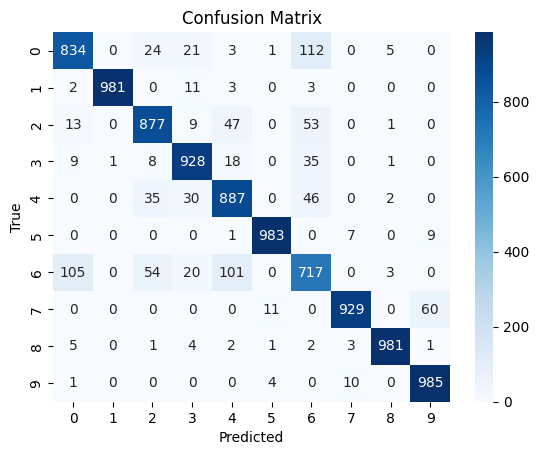

In [42]:
# make a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, np.argmax(predictions, axis=1))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()  